# Basic usage

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biprateep/lazy-tfm/blob/tutorials/basic_usage.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?logo=github)](https://github.com/biprateep/lazy-tfm/blob/tutorials/basic_usage.ipynb)

This tutorial walks through the core workflow of `lazy` on a standard
regression dataset, the median house values of California districts. We fit
a model, ask it for point predictions, intervals and quantiles, check
whether its intervals are as wide as they should be, and score its
predicted distributions, all with the scikit-learn interface.

## Setup

When the notebook runs on Google Colab, the cell below installs the package
with the TabPFN backend. Elsewhere, the package needs to be installed first
with `pip install 'lazy-tfm[tabpfn]'`. On Colab, choose
*Runtime → Change runtime type → T4 GPU*.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q 'lazy-tfm[tabpfn]'
    pass

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import model_selection

import lazy
from lazy import datasets
from lazy import plotting

SEED = 42  # One seed for the split, the subsample and the model

plotting.use_style()
plt.rcParams["figure.dpi"] = 110  # Readable in a notebook

## The data

`datasets.load_dataset` downloads a dataset by name the first time it is
called and reads it from a local cache after that (the
[Demo datasets](https://lazy-tfm.readthedocs.io/en/latest/guide/datasets.html)
page lists them all). The California housing dataset has 20,640 districts,
each described by eight features (e.g., the median income, the age of the
houses, the number of rooms, the location, etc.), and the target is the
median house value in US dollars. We divide the target by 100,000 so that
the numbers and axes below read in units of \$100,000. The values in the
source were capped at \$500,001, and we count the districts at the cap.

In [3]:
X, y = datasets.load_dataset("california_housing", return_X_y=True)
y = y / 1e5  # In units of $100,000
print(f"{(y == y.max()).sum()} districts at the cap of {y.max()}")
X.head()

965 districts at the cap of 5.00001


,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome
0,-122.23,37.88,41,880,129,322,126,8.3252
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014
2,-122.24,37.85,52,1467,190,496,177,7.2574
3,-122.25,37.85,52,1274,235,558,219,5.6431
4,-122.25,37.85,52,1627,280,565,259,3.8462


We hold out 20% of the districts as a test set with scikit-learn's
`train_test_split`. The remaining districts are the labeled rows that the
model will see as its context. To keep this tutorial quick, we use a random
5,000 of them rather than all 16,512.

In [4]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
rng = np.random.default_rng(SEED)
rows = rng.choice(len(X_train), size=5_000, replace=False)
X_train, y_train = X_train.iloc[rows], y_train[rows]

print(f"{len(X_train):,} context rows, {len(X_test):,} test rows")

5,000 context rows, 4,128 test rows


## The model

`lazy.LazyModel()` with no arguments uses TabPFN-3.5. `fit` does not train
anything. It checks the features and stores the labeled rows as the context,
and the model then predicts each test row in a forward pass conditioned on
that context. The first call also downloads the weights of the model, which
are cached after that.

In [5]:
model = lazy.LazyModel(random_state=SEED)
model.fit(X_train, y_train)

,version,'v3.5'
,n_estimators,8
,transforms,'auto'
,feature_shuffle,True
,bag_size,None
,kv_cache,True
,device,'auto'
,random_state,42
,chunk_size,8192
,softmax_temperature,'auto'
,mixed_precision,True


## Point predictions

The model predicts a full distribution of the house value for each district.
`predict` reduces it to one number, by default its mode (`method="mode"`),
and `method="mean"` and `method="median"` give the other common choices.
They differ most when a distribution is skewed or has more than one peak.

In [6]:
points = pd.DataFrame(
    {
        method: model.predict(X_test, method=method)
        for method in ["mean", "median", "mode"]
    }
)
points["truth"] = y_test
points.head()

,mean,median,mode,truth
0,0.496974,0.497583,0.499498,0.47700
1,0.526467,0.507629,0.492725,0.45800
2,4.918678,4.993203,4.996677,5.00001
3,2.329697,2.312565,2.250282,2.18600
4,2.861996,2.799204,2.639722,2.78000


For these five districts, the three estimates agree to within about
\$22,000, and the largest difference is between the mean and the mode of
the fifth district (2.86 vs. 2.64). To obtain several point estimates
without running the model once for each, we can instead call `predict_proba`
once and pass its output to `model.point_estimates`.

## Intervals and quantiles

`predict_interval` returns the central interval holding a given probability
of each distribution, and `predict_quantiles` returns any quantiles we ask
for. Both are computed exactly from the model's own output rather than from
a grid. Here we ask for the 68% interval, and for the 16th, 50th and 84th
percentiles, which give the same interval and the median.

In [7]:
interval = model.predict_interval(X_test, coverage=0.68)
q = model.predict_quantiles(X_test, [0.16, 0.5, 0.84])
print(interval[:3])
print(q[:3])

[[0.43692668 0.55306028]
 [0.34962294 0.67199257]
 [4.93673917 5.03899865]]
[[0.43692668 0.49758253 0.55306028]
 [0.34962294 0.50762933 0.67199257]
 [4.93673917 4.99320256 5.03899865]]


The first and last columns of the quantiles are the bounds of the interval,
and the middle column is the median. The interval of the third district,
whose true value is at the cap, reaches 5.04, above any value in the data,
since nothing tells the model that the values stop at the cap.

To see what these predictions look like, we plot the median and the 68%
interval for 40 random test districts, sorted by their true value.

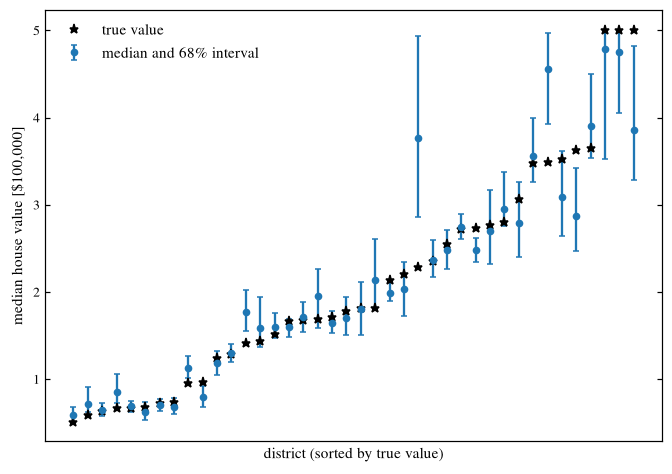

In [8]:
sample = rng.choice(len(X_test), size=40, replace=False)
sample = sample[np.argsort(y_test[sample])]
x = np.arange(sample.size)

fig, ax = plt.subplots(figsize=(6, 4.2), layout="constrained")
ax.errorbar(
    x,
    q[sample, 1],
    yerr=[q[sample, 1] - q[sample, 0], q[sample, 2] - q[sample, 1]],
    fmt="o",
    ms=4,
    capsize=2,
    label="median and 68% interval",
)
ax.plot(x, y_test[sample], "k*", ms=6, label="true value")
ax.set_xlabel("district (sorted by true value)")
ax.set_ylabel("median house value [\\$100,000]")
ax.set_xticks([])
ax.legend()
plt.show()

The figure shows the predicted median (blue points) and the 68% interval
(blue bars) of each district, with the true value as a black star. We see
that the medians follow the true values closely for most of the cheaper
districts, where the intervals are also narrow. The intervals widen for the
more expensive districts, and the true value of one district near \$230,000
lies far below its interval, whose median is near \$380,000. The three most
expensive districts in the sample sit at the cap of the data, and the model
predicts them with medians below it (two near \$480,000 and one near
\$390,000).

## Calibration

If the distributions are calibrated, the true value should fall inside the
68% interval for 68% of the districts. We count how often it does.

In [9]:
inside = (interval[:, 0] <= y_test) & (y_test <= interval[:, 1])
print(
    f"True value inside the 68% interval for {inside.mean():.1%} of districts"
)

True value inside the 68% interval for 68.9% of districts


A finer test is the probability integral transform (PIT), which is the
predicted cumulative distribution evaluated at the true value. For
calibrated distributions, the PIT values are uniform between 0 and 1. We
compute them exactly from the model's own output with `predict_pit`, as for
the quantiles above, and plot their histogram with `plotting.plot_pit`.

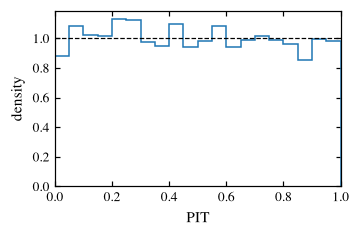

In [10]:
pit = model.predict_pit(X_test, y_test)

ax = plotting.plot_pit(pit)

The figure shows the histogram of the PIT values (blue) and the uniform
distribution expected for calibrated predictions (dashed line). We see
that the histogram is close to flat, with no U shape (which would mean
intervals that are too narrow), no dome (too wide) and no slope (biased).
This agrees with the 68.9% coverage of the 68% interval above.

## Scoring

`evaluate` scores the predictions with the full set of metrics and returns
them as a one-row table. The PDF metrics are the conditional density
estimate (CDE) loss, the continuous ranked probability score (`crps`) and
the negative log likelihood (`nll`), for all of which lower is better,
together with statistics of the PIT values. The point metrics score the
mode, in the units of the target. The
[From model output to distribution](https://lazy-tfm.readthedocs.io/en/latest/guide/distributions.html#metrics)
page defines every column.

In [11]:
model.evaluate(X_test, y_test).T

,0
model,tabpfn:v3.5
point_estimate,mode
scale,none
n,4128
bias,-0.014077
sigma_mad,0.190166
sigma_iqr,0.191567
outlier_rate,0.108043
outlier_threshold,0.574701
outlier_rate_015,0.453246


`score` returns a single number, minus the CDE loss, so that higher is
better, as scikit-learn tools such as `GridSearchCV` expect.

In [12]:
model.score(X_test, y_test)

1.9398811089584285

The CDE loss of our predictions is $-1.94$, which `score` returns as $1.94$.
The CRPS is 0.172, in the units of the target (i.e., about \$17,000), and
the NLL is $-0.095$. The PIT statistics agree with the histogram above, with
a Kolmogorov-Smirnov p-value of 0.26 and no PIT values within $10^{-4}$ of
0 or 1 (`pit_outlier_rate`), which would mark catastrophic failures. These
numbers are most useful when compared with those of another model or
another context on the same test set.

## Next steps

This tutorial covered the steps that every analysis with `lazy` shares.
The next tutorials build on them. The
[multimodal targets](https://lazy-tfm.readthedocs.io/en/latest/tutorials/multimodal.html)
tutorial looks at targets whose distributions have more than one peak,
where the point estimates above disagree, and the
[choosing a model](https://lazy-tfm.readthedocs.io/en/latest/tutorials/choosing_a_model.html)
tutorial compares the available models, each of which
`lazy.LazyModel(name)` selects by name. To use all 16,512 training
districts as the context, we can drop the subsample above, at the cost of a
slower forward pass for every prediction (about three times as many context
rows). The
[From model output to distribution](https://lazy-tfm.readthedocs.io/en/latest/guide/distributions.html)
page gives the background on grids, point estimates and the metrics.